## Level 4: Model Training and Evaluation

### Objective
To train a Linear Regression model for predicting train journey duration and evaluate its performance using MAE and RMSE.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
train_journey = pd.read_csv("train_journey_cleaned.csv")
train_journey.head()

,Train_No,Start_Station,End_Station,Total_Distance,Number_of_Stops,Journey_Duration
0,107,SAWANTWADI R,MADGOAN JN.,78,4,105.0
1,108,MADGOAN JN.,SAWANTWADI R,83,4,115.0
2,128,MADGOAN JN.,CHHATRAPATI,978,22,1325.0
3,290,DELHI-SAFDAR,DELHI-SAFDAR,2694,14,480.0
4,401,AURANGABAD,VARANASI JN.,1618,12,750.0


In [4]:
print("Rows:", train_journey.shape[0])
print("Columns:", train_journey.shape[1])

train_journey.info()

Rows: 11113
Columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Train_No          11113 non-null  int64  
 1   Start_Station     11113 non-null  object 
 2   End_Station       11113 non-null  object 
 3   Total_Distance    11113 non-null  int64  
 4   Number_of_Stops   11113 non-null  int64  
 5   Journey_Duration  11113 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 521.1+ KB


In [5]:
X = train_journey[
    ["Total_Distance", "Number_of_Stops"]
]

y = train_journey["Journey_Duration"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
   Total_Distance  Number_of_Stops
0              78                4
1              83                4
2             978               22
3            2694               14
4            1618               12

Target:
0     105.0
1     115.0
2    1325.0
3     480.0
4     750.0
Name: Journey_Duration, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 8890
Testing records: 2223


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [8]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[368.70712897 262.12835    195.54327945 129.65859509 246.74881703
  94.99288723 292.48926408  92.50059034 707.3520751  526.25142439]


In [9]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 152.21215044404454
Root Mean Squared Error (RMSE): 237.38671754227823


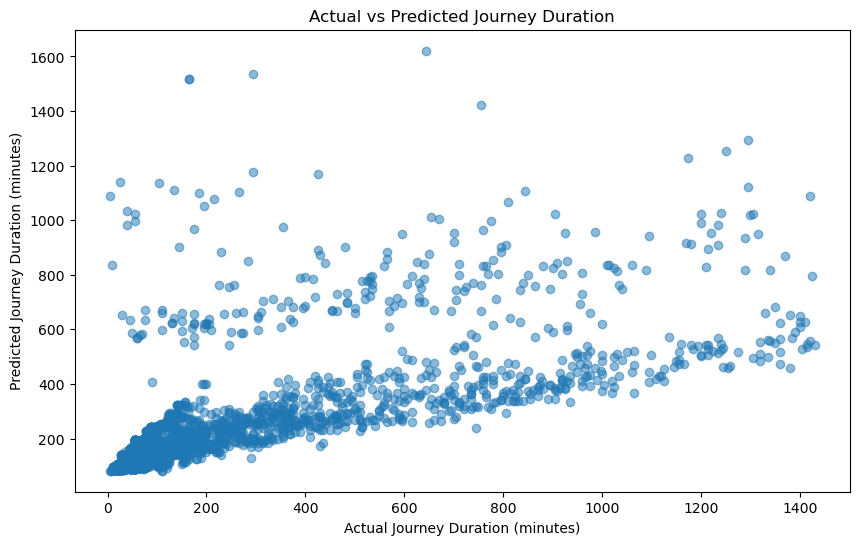

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Journey Duration (minutes)")
plt.ylabel("Predicted Journey Duration (minutes)")
plt.title("Actual vs Predicted Journey Duration")

plt.show()

In [11]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [12]:
import os

print(os.path.exists("linear_regression_model.pkl"))

True


In [13]:
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 152.21215044404454
RMSE: 237.38671754227823


In [14]:
comparison = pd.DataFrame({
    "Actual_Duration": y_test.values,
    "Predicted_Duration": y_pred
})

comparison["Error"] = (
    comparison["Actual_Duration"] -
    comparison["Predicted_Duration"]
)

comparison.head(10)

,Actual_Duration,Predicted_Duration,Error
0,690.0,368.707129,321.292871
1,180.0,262.128350,-82.128350
2,55.0,195.543279,-140.543279
3,190.0,129.658595,60.341405
4,113.0,246.748817,-133.748817
5,38.0,94.992887,-56.992887
6,450.0,292.489264,157.510736
7,59.0,92.500590,-33.500590
8,705.0,707.352075,-2.352075
9,1185.0,526.251424,658.748576


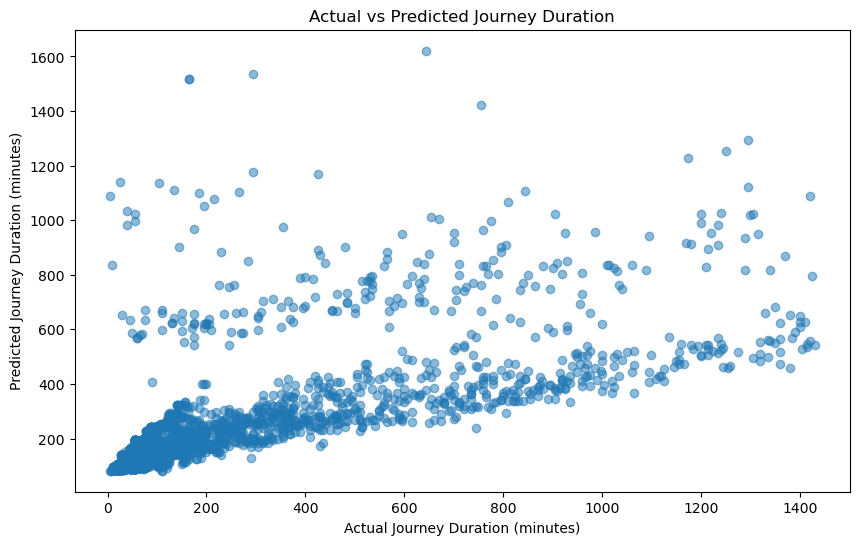

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Journey Duration (minutes)")
plt.ylabel("Predicted Journey Duration (minutes)")
plt.title("Actual vs Predicted Journey Duration")

plt.show()

## Level 4 Summary

A Linear Regression model was trained to predict train journey duration using Total Distance and Number of Stops as input features.

The dataset was divided into training and testing sets using an 80:20 split.

The model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). An actual vs predicted visualization was also created to analyze the model's prediction performance.

The trained Linear Regression model was saved as `linear_regression_model.pkl`.